# 1. Business Understanding

## Introduction
This project seeks to analyze and classify images as either **real-world photographs** or **AI-generated images**, with the goal of developing a reliable **image authenticity detection model**. To achieve this, the project focuses on a predictive model:
- A **binary classification model** to distinguish between real and AI-generated images across multiple categories, including nature, city, animals, food, and people.

By leveraging computer vision and deep learning techniques, the analysis provides a comprehensive understanding of differences between real and AI-generated images, enabling automated detection and verification.

---

## Business Understanding
The central research question guiding this project is:

**“Can we accurately distinguish between real photographs and AI-generated images using machine learning?”**

The motivation behind this study stems from the increasing presence of AI-generated content in digital media. With AI tools like Stable Diffusion producing photorealistic images, organizations, social media platforms, and content creators face challenges in maintaining **content authenticity and trustworthiness**. Automating the detection of synthetic content helps reduce risks associated with misinformation, fraud, and compromised digital assets.

This project is particularly relevant to the **digital media and content verification sector**. Its target audience includes:
- **Social media platforms and digital publishers** – who need to ensure the authenticity of user-generated or curated content.
- **Businesses and marketing teams** – who aim to maintain brand credibility by verifying image authenticity in campaigns.
- **AI developers and researchers** – who can use insights to improve generative model evaluation and synthetic content detection.

The model developed in this project serves as a **decision-support tool** for content verification:
- The **binary classification model** helps stakeholders automatically identify AI-generated images versus real ones.
- It also provides insights into patterns and visual cues that differentiate real-world images from synthetic ones, enhancing detection strategies.

By combining deep learning techniques with carefully curated real and synthetic datasets, this project aims to provide a **data-driven foundation for understanding and detecting AI-generated content**, supporting trust and integrity in digital media.

# 2.0  Data Understanding 
 
 ### 2.1 import libraries 

In [2]:
# ---------------------------
# 1. Basic Libraries
# ---------------------------
import os                # For file/directory operations
import shutil            # For file copying/moving
import random            # For reproducibility and random operations
import glob              # For pattern-based file searching
import zipfile           # If your dataset comes as zip

# ---------------------------
# 2. Data Manipulation & Visualization
# ---------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# 3. Image Processing
# ---------------------------
from PIL import Image    # Image loading and processing
            # Optional: OpenCV for advanced image operations

# ---------------------------
# 4. Machine Learning / Deep Learning
# ---------------------------
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import ResNet50, VGG16, EfficientNetB0

# ---------------------------
# 5. Evaluation Metrics
# ---------------------------
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

# ---------------------------
# 6. Reproducibility
# ---------------------------
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

### 2.2 Import Data 

In [3]:
import os
import numpy as np
from PIL import Image

# Paths to dataset
DATA_DIR = "Data"
CLASS_DIRS = {
    "real": "real_dataset",
    "ai_generated": "Ai_generated_dataset"
}

# Settings
IMG_SIZE = (224, 224)  # resize all images

# Lists to store images and labels
images = []
labels = []

# Load all images
for label_name, folder_name in CLASS_DIRS.items():
    class_path = os.path.join(DATA_DIR, folder_name)
    for category in os.listdir(class_path):
        category_path = os.path.join(class_path, category)
        if os.path.isdir(category_path):
            for img_file in os.listdir(category_path):
                img_path = os.path.join(category_path, img_file)
                try:
                    img = Image.open(img_path).convert("RGB")
                    img = img.resize(IMG_SIZE)
                    images.append(np.array(img))
                    labels.append(0 if label_name == "real" else 1)
                except:
                    pass  # skip unreadable images

# Convert to NumPy arrays
X = np.array(images)
y = np.array(labels)

print("Data loaded successfully!")
print("Total images:", len(X))
print("X shape:", X.shape)
print("y shape:", y.shape)

Data loaded successfully!
Total images: 995
X shape: (995, 224, 224, 3)
y shape: (995,)


### 2.3 Check Missing / Corrupt Images

In [4]:
# Check for missing values in images
print("Missing values in X:", np.isnan(X).sum())
print("Missing values in y:", np.isnan(y).sum())

# Check if any images are empty or invalid
invalid_images = [i for i, img in enumerate(X) if img.shape != (224, 224, 3)]

print("Number of invalid images:", len(invalid_images))

Missing values in X: 0
Missing values in y: 0
Number of invalid images: 0


### 2.4 Check Class Distribution (Imbalance)

Counter({0: 745, 1: 250})


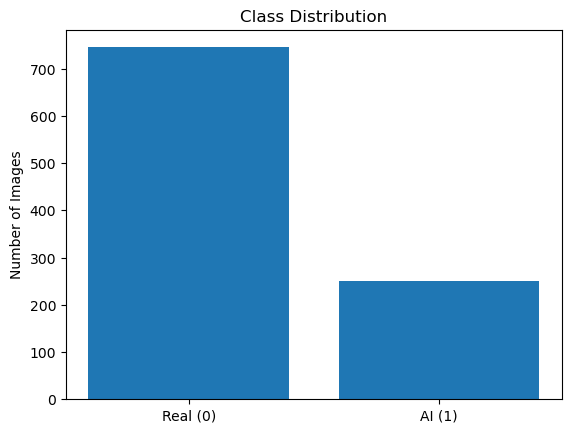

In [5]:
import collections

counter = collections.Counter(y)
print(counter)

# Visualize distribution
import matplotlib.pyplot as plt

labels = ['Real (0)', 'AI (1)']
values = [counter[0], counter[1]]

plt.bar(labels, values)
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()

### 2.5 Percentage Distribution

In [6]:
total = len(y)
real_pct = (counter[0] / total) * 100
ai_pct = (counter[1] / total) * 100

print(f"Real Images: {real_pct:.2f}%")
print(f"AI Images: {ai_pct:.2f}%")

Real Images: 74.87%
AI Images: 25.13%


### 2.6 Visualize Sample Real vs AI Images

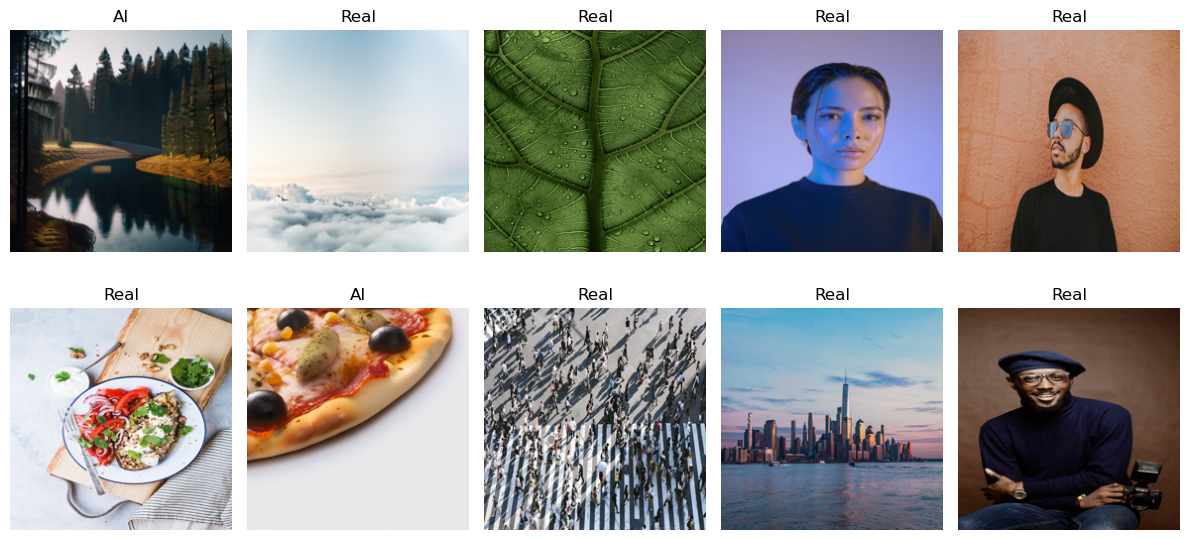

In [7]:
# Show random sample images
import matplotlib.pyplot as plt
import numpy as np

# Select random indices
indices = np.random.choice(len(X), 10, replace=False)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(indices):
    plt.subplot(2, 5, i+1)
    plt.imshow(X[idx])
    plt.title("Real" if y[idx] == 0 else "AI")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 3. Data Preparation (Preprocessing)

In [8]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ===============================
# 1. Settings
# ===============================
DATA_DIR = "Data"
CLASS_DIRS = {
    "real": "real_dataset",
    "ai_generated": "Ai_generated_dataset"
}
IMG_SIZE = (224, 224)
batch_size = 32

# ===============================
# 2. Load Images and Labels
# ===============================
images = []
labels = []

for label_name, folder_name in CLASS_DIRS.items():
    class_path = os.path.join(DATA_DIR, folder_name)
    if not os.path.exists(class_path):
        continue
    for category in os.listdir(class_path):
        category_path = os.path.join(class_path, category)
        if os.path.isdir(category_path):
            for img_file in os.listdir(category_path):
                img_path = os.path.join(category_path, img_file)
                try:
                    img = Image.open(img_path).convert("RGB")
                    img = img.resize(IMG_SIZE)
                    images.append(np.array(img))
                    labels.append(0 if label_name == "real" else 1)
                except:
                    continue  # skip unreadable images

# Convert to NumPy arrays
X = np.array(images, dtype=np.float32) / 255.0  # normalize to [0,1]
y = np.array(labels, dtype=np.int32)

print("Images loaded:", X.shape[0])
print("Labels loaded:", y.shape[0])
print("Unique labels:", np.unique(y))

# ===============================
# 3. Train / Validation / Test Split
# ===============================
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

# ===============================
# 4. Data Augmentation
# ===============================
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(X_train, y_train, batch_size=batch_size)
val_generator = val_datagen.flow(X_val, y_val, batch_size=batch_size)
test_generator = test_datagen.flow(X_test, y_test, batch_size=batch_size, shuffle=False)

print("Data preprocessing complete.")

Images loaded: 995
Labels loaded: 995
Unique labels: [0 1]
Train: (597, 224, 224, 3) (597,)
Validation: (199, 224, 224, 3) (199,)
Test: (199, 224, 224, 3) (199,)
Data preprocessing complete.


# 4.0 Modelling 

### 4.1 Transfer Learning with MobileNetV2   as the Baseline  Model

Fit the Model 

In [9]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']        

Train the Model 

In [10]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
19/19 [==============================] - 18s 793ms/step - loss: 0.6496 - accuracy: 0.6750 - val_loss: 0.5678 - val_accuracy: 0.7437
Epoch 2/15
19/19 [==============================] - 15s 766ms/step - loss: 0.4942 - accuracy: 0.7856 - val_loss: 0.4770 - val_accuracy: 0.8040
Epoch 3/15
19/19 [==============================] - 15s 776ms/step - loss: 0.4210 - accuracy: 0.8291 - val_loss: 0.4245 - val_accuracy: 0.8040
Epoch 4/15
19/19 [==============================] - 14s 758ms/step - loss: 0.3624 - accuracy: 0.8543 - val_loss: 0.3731 - val_accuracy: 0.8744
Epoch 5/15
19/19 [==============================] - 14s 764ms/step - loss: 0.3114 - accuracy: 0.8827 - val_loss: 0.3450 - val_accuracy: 0.8744
Epoch 6/15
19/19 [==============================] - 14s 748ms/step - loss: 0.2703 - accuracy: 0.9162 - val_loss: 0.3212 - val_accuracy: 0.8744
Epoch 7/15
19/19 [==============================] - 15s 787ms/step - loss: 0.2390 - accuracy: 0.9095 - val_loss: 0.3047 - val_accuracy: 0.8794

### 5.0 Evaluation 

In [11]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

7/7 [==============================] - 3s 421ms/step - loss: 0.1651 - accuracy: 0.9347
Test Accuracy: 0.9346733689308167


In [12]:
from sklearn.metrics import confusion_matrix, classification_report

y_prob = model.predict(test_generator).ravel()
y_pred = (y_prob > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

7/7 [==============================] - 4s 427ms/step
[[145   4]
 [  9  41]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       149
           1       0.91      0.82      0.86        50

    accuracy                           0.93       199
   macro avg       0.93      0.90      0.91       199
weighted avg       0.93      0.93      0.93       199



In [13]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
19/19 [==============================] - 21s 934ms/step - loss: 0.2062 - accuracy: 0.9246 - val_loss: 0.2070 - val_accuracy: 0.9196
Epoch 2/10
19/19 [==============================] - 17s 912ms/step - loss: 0.1812 - accuracy: 0.9397 - val_loss: 0.1972 - val_accuracy: 0.9347
Epoch 3/10
19/19 [==============================] - 18s 928ms/step - loss: 0.1729 - accuracy: 0.9363 - val_loss: 0.1915 - val_accuracy: 0.9296
Epoch 4/10
19/19 [==============================] - 17s 894ms/step - loss: 0.1281 - accuracy: 0.9665 - val_loss: 0.1876 - val_accuracy: 0.9347
Epoch 5/10
19/19 [==============================] - 17s 874ms/step - loss: 0.1350 - accuracy: 0.9564 - val_loss: 0.1859 - val_accuracy: 0.9397
Epoch 6/10
19/19 [==============================] - 17s 873ms/step - loss: 0.1219 - accuracy: 0.9648 - val_loss: 0.1826 - val_accuracy: 0.9397
Epoch 7/10
19/19 [==============================] - 18s 927ms/step - loss: 0.1148 - accuracy: 0.9665 - val_loss: 0.1804 - val_accuracy: 0.9397

In [14]:
y_prob = model.predict(test_generator).ravel()
y_pred = (y_prob > 0.5).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

7/7 [==============================] - 4s 453ms/step
[[145   4]
 [  6  44]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       149
           1       0.92      0.88      0.90        50

    accuracy                           0.95       199
   macro avg       0.94      0.93      0.93       199
weighted avg       0.95      0.95      0.95       199



### Confusion Matrix

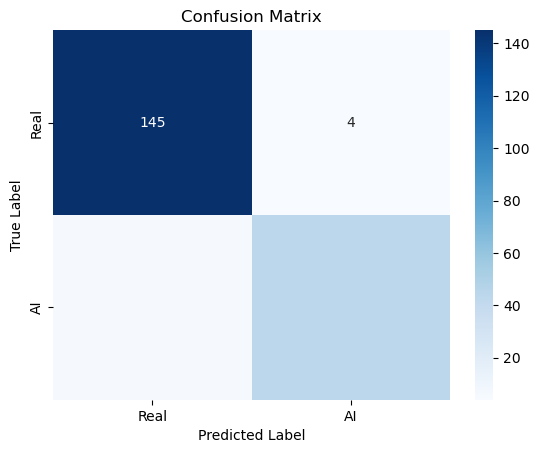

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Real", "AI"],
            yticklabels=["Real", "AI"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### Confusion Matrix

This heatmap shows how well the model classifies images into **Real (0)** and **AI Generated (1)**.

- **Top-left (145)** → Correctly predicted Real images (True Negatives)
- **Top-right (4)** → Real images incorrectly predicted as AI (False Positives)
- **Bottom-left (6)** → AI images incorrectly predicted as Real (False Negatives)
- **Bottom-right (44)** → Correctly predicted AI images (True Positives)

### ROC Curve

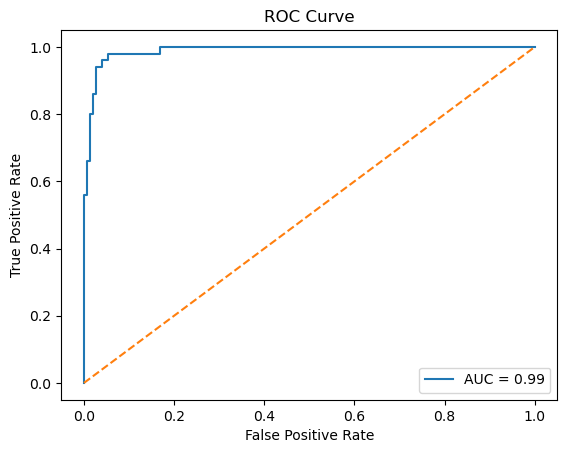

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### ROC Curve (Receiver Operating Characteristic)

The ROC curve shows how well the model separates the two classes across different thresholds.

- The curve is very close to the **top-left corner**, which indicates excellent performance.
- The dashed diagonal line represents a random classifier.
- **AUC = 0.99**, meaning the model has an almost perfect ability to distinguish between Real and AI images.

### Precision-Recall Curve

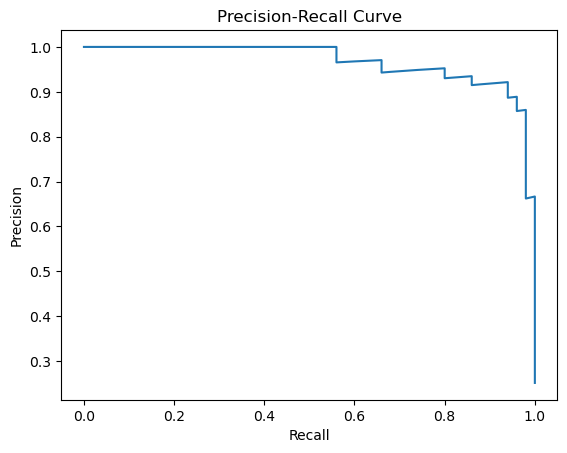

In [17]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

### Precision-Recall Curve

This curve focuses on the performance of the model for the **AI Generated class (positive class)**.

- **Precision** → How many predicted AI images are actually AI
- **Recall** → How many actual AI images are correctly detected

- The curve stays very high (close to 1.0), meaning:
  - High precision → Few false alarms
  - High recall → Most AI images are detected

### Training History

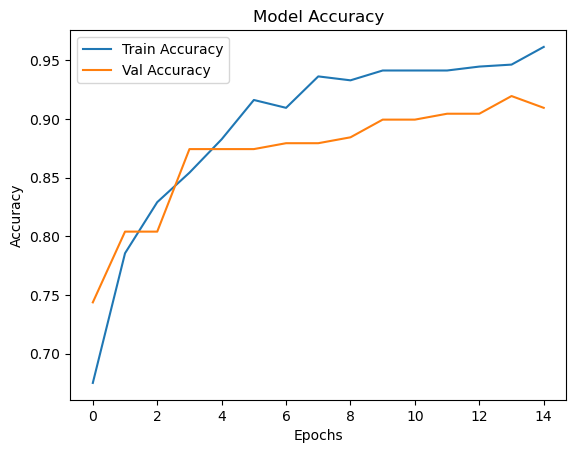

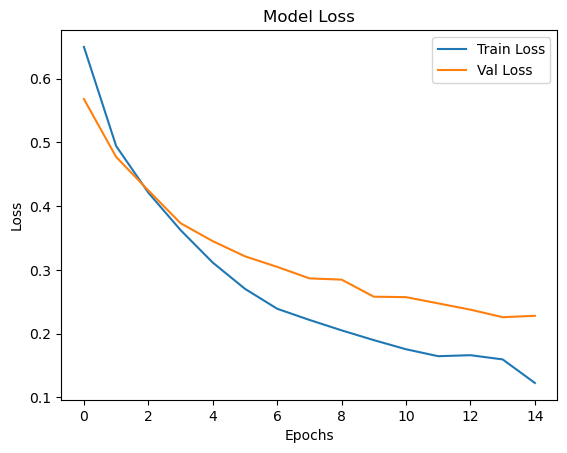

In [18]:
# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Accuracy Curve (Model Learning Behavior)

The accuracy plot shows how well the model learns over time on both training and validation data.

- **Steady Learning Phase:**  
  Both training and validation accuracy increase together in the early epochs, indicating that the model quickly learns meaningful patterns that distinguish Real and AI images.

- **Plateau Phase:**  
  Around Epoch 10, validation accuracy stabilizes at approximately **91%**, suggesting that the model has extracted most of the useful general features.

- **Overfitting Gap:**  
  Training accuracy continues to improve while validation accuracy remains constant.  
  This growing gap indicates **overfitting**, where the model begins to memorize training data instead of generalizing to unseen data.

  ### Loss Curve (Model Error Behavior)

The loss curve represents how the model’s prediction error changes during training.

- **Rapid Error Reduction:**  
  Both training and validation loss decrease sharply in the early stages, showing effective learning and optimization.

- **Divergence Point:**  
  Around Epoch 7, training loss continues to decrease smoothly, while validation loss begins to fluctuate and flatten.

- **Learning Saturation:**  
  When validation loss stops improving, the model has reached its **learning limit** on this dataset.

### Show Sample Predictions

1/1 [==============================] - 0s 48ms/step


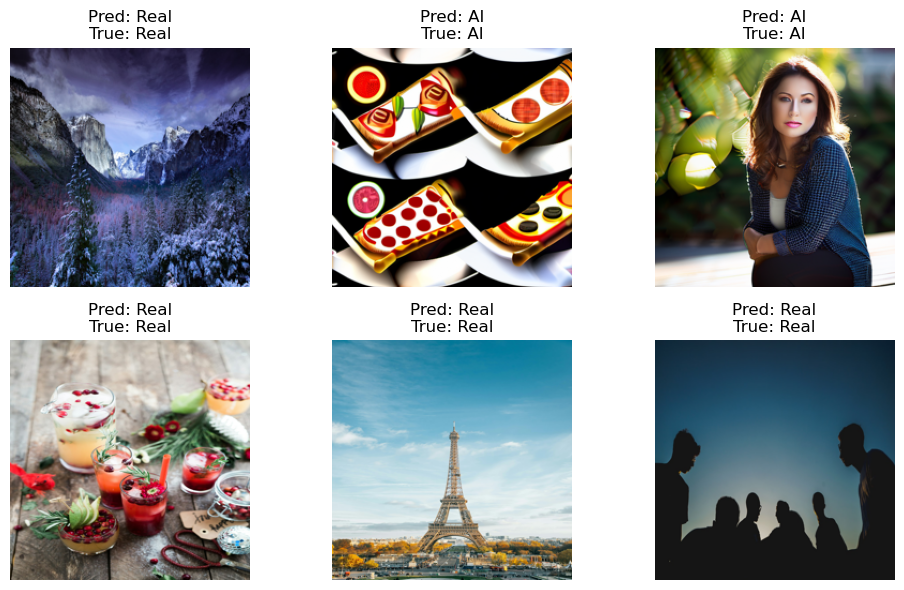

In [19]:
import random

plt.figure(figsize=(10,6))

for i in range(6):
    idx = random.randint(0, len(X_test)-1)
    img = X_test[idx]
    
    pred = model.predict(np.expand_dims(img, axis=0))[0][0]
    label = "AI" if pred > 0.5 else "Real"
    true = "AI" if y_test[idx] == 1 else "Real"
    
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"Pred: {label}\nTrue: {true}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 6.0 Save The Model 

In [20]:
model.evaluate(val_generator)

7/7 [==============================] - 3s 443ms/step - loss: 0.1679 - accuracy: 0.9397


[0.1678648293018341, 0.9396985173225403]

In [21]:
import numpy as np
sample = np.random.rand(1, 224, 224, 3)
print(model.predict(sample))

1/1 [==============================] - 0s 67ms/step
[[0.00916518]]


In [22]:
model.save("ai_vs_real_model.h5")
print("Model saved successfully!")

c:\Users\Admin\anaconda3\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved successfully!


In [23]:
from tensorflow.keras.models import load_model

model = load_model("ai_vs_real_model.h5", compile=False)

print("Model loaded!")

# Test prediction
import numpy as np
sample = np.random.rand(1, 224, 224, 3)
print(model.predict(sample))

Model loaded!
1/1 [==============================] - 1s 731ms/step
[[0.00690661]]


In [24]:
model.save("ai_vs_real_model.keras")

In [25]:
model = load_model("ai_vs_real_model.h5", compile=False)

In [26]:
# Save the trained model
model.save("ai_vs_real_model.h5")   # 👈 use .h5 (recommended)
print("Model saved successfully!")

# Save class labels
import pickle

class_names = ["Real", "AI"]

with open("labels.pkl", "wb") as f:
    pickle.dump(class_names, f)

print("Class labels saved successfully!")

Model saved successfully!
Class labels saved successfully!


In [27]:
from tensorflow.keras.models import load_model
import pickle
import streamlit as st

@st.cache_resource
def load_model_and_labels():
    model = load_model("ai_vs_real_model.h5", compile=False)
    
    with open("labels.pkl", "rb") as f:
        class_names = pickle.load(f)
    
    return model, class_names

model, class_names = load_model_and_labels()

2026-04-06 04:32:18.736 
  command:

    streamlit run c:\Users\Admin\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]


In [28]:
model.save("ai_vs_real_model.h5")